In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.losses import MeanSquaredError

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/Final Year Project/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Final Year Project')

from data_preprocessor import DataPreprocessor

preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train_norm = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train_norm.shape)



Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [ ]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test_norm = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test_norm.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Check GPU availability
print("="*60)
print("GPU CHECK")
print("="*60)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {gpus}")

    # Set memory growth to avoid OOM
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"   Memory growth set for {gpu.name}")
        except RuntimeError as e:
            print(f"   ❌ Could not set memory growth for {gpu.name}: {e}")
            print("      This usually means the GPU devices have already been initialized.")

    # Verify tensor placement
    with tf.device('/GPU:0'):
        test_tensor = tf.random.normal((100, 100))
        result = tf.matmul(test_tensor, test_tensor)
    print(f"✅ GPU test successful: {result.device}")
else:
    print("❌ No GPU found - training will be slow!")

print("="*60)

GPU CHECK
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Memory growth set for /physical_device:GPU:0
✅ GPU test successful: /job:localhost/replica:0/task:0/device:GPU:0


In [ ]:
@tf.function
def train_step(
    model, optimizer,
    x_ic, x_ctx, y,
    scaler_std,
    clip_min, clip_max,
):
    # ===== Strong fixed JSMA attack =====
    x_adv = targeted_rjsma_attack(
        model=model,
        X_ic_test=x_ic,
        X_context_test=x_ctx,
        y_test=y,
        epsilon=5.0,
        k=3,
        num_steps=10,
        target_shift=0.1,
        clip_min=clip_min,
        clip_max=clip_max,
        scaler_std=scaler_std,
    )

    # ===== Forward + robust loss =====
    with tf.GradientTape() as tape:
        y_clean = model([x_ic, x_ctx], training=True)
        y_adv   = model([x_adv, x_ctx], training=True)

        loss_clean = tf.reduce_mean(tf.square(y - y_clean))
        loss_adv   = tf.reduce_mean(tf.square(y - y_adv))

        # 🔥 Robust-focused weighting
        loss = 0.2 * loss_clean + 0.8 * loss_adv

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    mae_clean = tf.reduce_mean(tf.abs(y - y_clean))
    mae_adv   = tf.reduce_mean(tf.abs(y - y_adv))

    return loss, mae_clean, mae_adv


In [ ]:
with tf.device('/GPU:0'):
  cnn_gru = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/CNN_GRU_NT.keras")

In [ ]:
# ===== JSMA ADV TRAIN CONFIG =====
lambda_clean = 0.5
epochs       = 50
lr           = 1e-4
patience     = 10

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

clip_min = np.percentile(X_ic_train, 0.5)
clip_max = np.percentile(X_ic_train, 99.5)

scaler_std = preprocessor.ic_scaler.scale_


In [ ]:
@tf.function
def val_step(
    model,
    x_ic, x_ctx, y,
    scaler_std,
    clip_min, clip_max,
):
    # clean prediction (for logging only)
    y_clean = model([x_ic, x_ctx], training=False)
    mse_clean = tf.reduce_mean(tf.square(y - y_clean))

    # ===== Strong JSMA attack =====
    x_adv = targeted_rjsma_attack(
        model=model,
        X_ic_test=x_ic,
        X_context_test=x_ctx,
        y_test=y,
        epsilon=5.0,
        k=3,
        num_steps=10,
        target_shift=0.1,
        clip_min=clip_min,
        clip_max=clip_max,
        scaler_std=scaler_std,
    )

    y_adv = model([x_adv, x_ctx], training=False)
    mse_adv = tf.reduce_mean(tf.square(y - y_adv))

    return mse_clean, mse_adv


In [ ]:
from sklearn.model_selection import train_test_split

y_train_tf = y_train_norm.reshape(-1,1).astype(np.float32)
y_test_tf = y_test_norm.reshape(-1,1).astype(np.float32)

X_ic_tr, X_ic_val, \
X_ctx_tr, X_ctx_val, \
y_tr, y_val = train_test_split(
    X_ic_train.astype(np.float32),
    X_context_train.astype(np.float32),
    y_train_tf,
    test_size=0.2,
    random_state=42
)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

batch_size = 32


train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_ic_tr, X_ctx_tr, y_tr))
    .shuffle(len(X_ic_tr))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_ic_val, X_ctx_val, y_val))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((
        X_ic_test.astype(np.float32),
        X_context_test.astype(np.float32),
        y_test_tf
    ))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)


In [ ]:
from tqdm import tqdm

best_val_adv = float("inf")
wait = 0
patience = 10

train_mse_history = []
train_mae_clean_history = []
train_mae_adv_history = []

val_mse_clean_history = []
val_mse_adv_history = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # ===== TRAIN =====
    train_loss = 0.0
    train_mae_clean = 0.0
    train_mae_adv = 0.0
    n = 0

    for x_ic, x_ctx, y in tqdm(train_dataset, desc="Training", leave=False):

        loss, mae_c, mae_a = train_step(
            cnn_gru, optimizer,
            x_ic, x_ctx, y,
            scaler_std,
            clip_min, clip_max,
        )

        train_loss += loss.numpy()
        train_mae_clean += mae_c.numpy()
        train_mae_adv += mae_a.numpy()
        n += 1

    avg_train_mse = train_loss / n
    avg_train_mae_clean = train_mae_clean / n
    avg_train_mae_adv = train_mae_adv / n

    train_mse_history.append(avg_train_mse)
    train_mae_clean_history.append(avg_train_mae_clean)
    train_mae_adv_history.append(avg_train_mae_adv)

    print(
        f"Train Loss: {avg_train_mse:.6f} | "
        f"MAE clean: {avg_train_mae_clean:.6f} | "
        f"MAE adv: {avg_train_mae_adv:.6f}"
    )

    # ===== VALIDATION =====
    val_clean = 0.0
    val_adv = 0.0
    m = 0

    for x_ic, x_ctx, y in tqdm(val_dataset, desc="Validation", leave=False):

        mse_c, mse_a = val_step(
            cnn_gru,
            x_ic, x_ctx, y,
            scaler_std,
            clip_min, clip_max,
        )

        val_clean += mse_c.numpy()
        val_adv += mse_a.numpy()
        m += 1

    val_clean /= m
    val_adv /= m

    val_mse_clean_history.append(val_clean)
    val_mse_adv_history.append(val_adv)

    print(f"Val MSE clean: {val_clean:.6f} | Val MSE adv: {val_adv:.6f}")

    # ===== ROBUSTNESS EARLY STOPPING =====
    if val_adv < best_val_adv:
        best_val_adv = val_adv
        wait = 0
        cnn_gru.save("/content/drive/MyDrive/Final Year Project/CNN_GRU_JSMA_ROBUST.keras")
        print("✅ Saved BEST JSMA-ROBUST model")
    else:
        wait += 1
        print(f"⚠️ No robustness improvement ({wait}/{patience})")

        if wait >= patience:
            print("⛔ Early stopping triggered (robustness plateau)")
            break



Epoch 1/50


Train Loss: 0.087608 | MAE clean: 0.144085 | MAE adv: 0.250655


Val MSE clean: 0.007693 | Val MSE adv: 0.086836
✅ Saved BEST JSMA-ROBUST model

Epoch 2/50


Train Loss: 0.084124 | MAE clean: 0.104662 | MAE adv: 0.250081


Val MSE clean: 0.005658 | Val MSE adv: 0.087503
⚠️ No robustness improvement (1/10)

Epoch 3/50


...

Val MSE clean: 0.003906 | Val MSE adv: 0.086920
⚠️ No robustness improvement (8/10)

Epoch 10/50


Train Loss: 0.082660 | MAE clean: 0.090991 | MAE adv: 0.248959


Val MSE clean: 0.003025 | Val MSE adv: 0.087200
⚠️ No robustness improvement (9/10)

Epoch 11/50


Train Loss: 0.083854 | MAE clean: 0.090312 | MAE adv: 0.251521


Val MSE clean: 0.003460 | Val MSE adv: 0.087201
⚠️ No robustness improvement (10/10)
⛔ Early stopping triggered (robustness plateau)


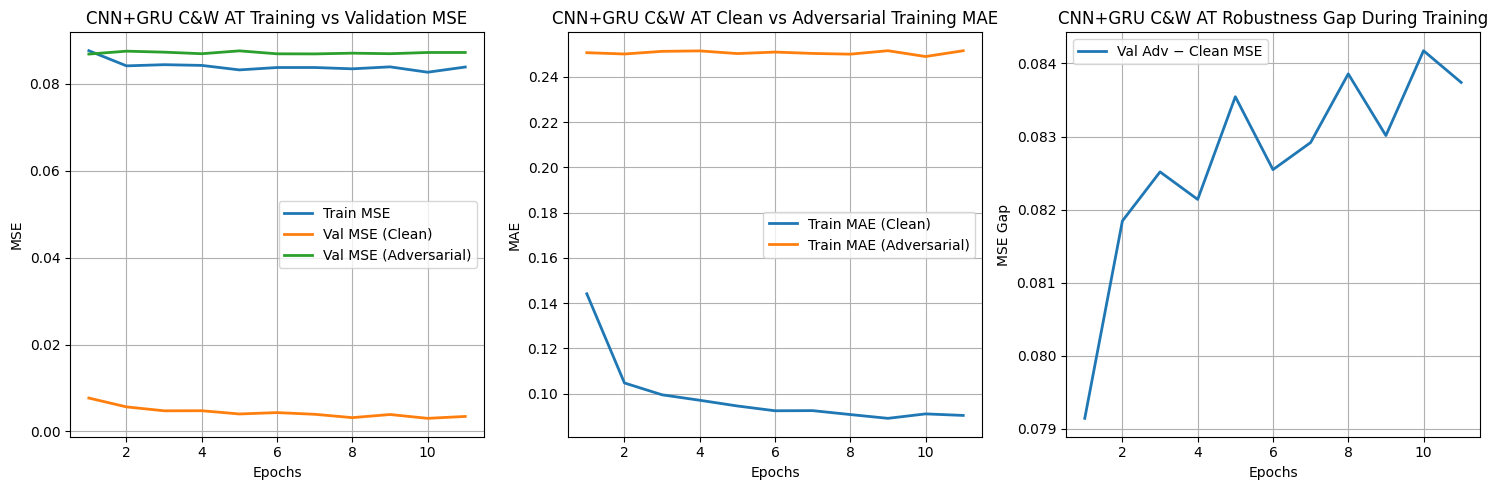

Saved FGSM adversarial training curves to:
/content/drive/MyDrive/Final Year Project/CNN+GRU_C&W_AT_training_curves.png


In [ ]:
import matplotlib.pyplot as plt

# Number of epochs actually completed
epochs_ran = len(train_mse_history)
epochs_axis = range(1, epochs_ran + 1)

plt.figure(figsize=(15, 5))

# ================= MSE Plot =================
plt.subplot(1, 3, 1)
plt.plot(epochs_axis, train_mse_history, label="Train MSE", linewidth=2)
plt.plot(epochs_axis, val_mse_clean_history, label="Val MSE (Clean)", linewidth=2)
plt.plot(epochs_axis, val_mse_adv_history, label="Val MSE (Adversarial)", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("CNN+GRU C&W AT Training vs Validation MSE")
plt.legend()
plt.grid(True)


# ================= MAE Plot (Train) =================
plt.subplot(1, 3, 2)
plt.plot(epochs_axis, train_mae_clean_history, label="Train MAE (Clean)", linewidth=2)
plt.plot(epochs_axis, train_mae_adv_history, label="Train MAE (Adversarial)", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("CNN+GRU C&W AT Clean vs Adversarial Training MAE")
plt.legend()
plt.grid(True)


# ================= Validation Gap Plot =================
plt.subplot(1, 3, 3)
gap = [a - b for a, b in zip(val_mse_adv_history, val_mse_clean_history)]
plt.plot(epochs_axis, gap, label="Val Adv − Clean MSE", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE Gap")
plt.title("CNN+GRU C&W AT Robustness Gap During Training")
plt.legend()
plt.grid(True)


plt.tight_layout()

# Save high-resolution figure
save_path = "/content/drive/MyDrive/Final Year Project/CNN+GRU_C&W_AT_training_curves.png"
plt.savefig(save_path, dpi=300)

plt.show()

print(f"Saved FGSM adversarial training curves to:\n{save_path}")


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from tabulate import tabulate


def compute_robustness_score(
    normal_model,
    adv_model,
    attack_fn,
    X_ic_test,
    X_context_test,
    y_test_norm,
    y_std,
    y_mean,
    epsilon,
    clip_min,
    clip_max,
    scaler_std,
    k,
    num_steps,
    target_shift,
):
    """
    Computes regression robustness based on
    absolute attacked MAE reduction (correct metric).
    """

    def evaluate(model):
        # ===== Clean prediction =====
        y_clean_norm = model.predict([X_ic_test, X_context_test], verbose=0).flatten()

        # ===== Generate adversarial samples =====
        X_adv = attack_fn(
            model=model,
            X_ic_test=X_ic_test,
            X_context_test=X_context_test,
            y_test=y_test_norm,
            epsilon=epsilon,
            scaler_std=scaler_std,
            clip_min=clip_min,
            clip_max=clip_max,
            k=k,
            num_steps=num_steps,
            target_shift=target_shift,
        )

        # ===== Attacked prediction =====
        y_adv_norm = model.predict([X_adv, X_context_test], verbose=0).flatten()

        # ===== Inverse scaling =====
        y_true = y_test_norm * y_std + y_mean
        y_clean = y_clean_norm * y_std + y_mean
        y_adv = y_adv_norm * y_std + y_mean

        # ===== Metrics =====
        mae_clean = mean_absolute_error(y_true, y_clean)
        mae_adv = mean_absolute_error(y_true, y_adv)
        delta_mae = mae_adv - mae_clean
        mape_adv = mean_absolute_percentage_error(y_true, y_adv)

        return mae_clean, mae_adv, delta_mae, mape_adv

    # ===== Evaluate both models =====
    normal_metrics = evaluate(normal_model)
    adv_metrics = evaluate(adv_model)

    # ===== CORRECT robustness gain =====
    robustness_gain = (
        (normal_metrics[1] - adv_metrics[1]) / normal_metrics[1]
    ) * 100.0

    # ===== Table =====
    table = [
        ["Normal Model", *normal_metrics, "—"],
        ["Adv-trained Model", *adv_metrics, f"{robustness_gain:.2f}%"],
    ]

    headers = [
        "Model",
        "MAE (Clean)",
        "MAE (Attacked)",
        "ΔMAE",
        "MAPE (Attacked)",
        "Robustness Gain (%)",
    ]

    print("\n=== Robustness Comparison ===")
    print(tabulate(table, headers=headers, floatfmt=".4f"))

    return {
        "normal": normal_metrics,
        "adv": adv_metrics,
        "robustness_gain_percent": robustness_gain,
    }


In [ ]:
cnn_gru_at = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/CNN_GRU_JSMA_CURRICULUM.keras")




In [ ]:
results = compute_robustness_score(
    normal_model=cnn_gru,      # normal trained CNN-GRU
    adv_model=cnn_gru_at,                # JSMA adversarially trained CNN-GRU
    attack_fn=targeted_rjsma_attack,

    X_ic_test=X_ic_test,
    X_context_test=X_context_test,
    y_test_norm=y_test_tf,
    y_std=y_std,
    y_mean=y_mean,

    epsilon=2,
    k=3,
    num_steps=5,
    target_shift=0.1,

    clip_min=clip_min,
    clip_max=clip_max,
    scaler_std=preprocessor.ic_scaler.scale_,
)


=== Robustness Comparison ===
Model                MAE (Clean)    MAE (Attacked)    ΔMAE    MAPE (Attacked)  Robustness Gain (%)
-----------------  -------------  ----------------  ------  -----------------  ---------------------
Normal Model              0.2946            1.5047  1.2101             0.0177  —
Adv-trained Model         1.3232            1.5092  0.1860             0.0178  -0.30%
